In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_text.csv to heart_disease_text.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import joblib

In [5]:
df = pd.read_csv("heart_disease_text.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145,233,gt_120,normal,150,no,2.3,upsloping,0,normal,1
1,37,Male,non_anginal,130,250,lt_120,st_t_wave,187,no,3.5,upsloping,0,fixed_defect,1
2,41,Female,atypical_angina,130,204,lt_120,normal,172,no,1.4,downsloping,0,fixed_defect,1
3,56,Male,atypical_angina,120,236,lt_120,st_t_wave,178,no,0.8,downsloping,0,fixed_defect,1
4,57,Female,typical_angina,120,354,lt_120,st_t_wave,163,yes,0.6,downsloping,0,fixed_defect,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    object 
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      301 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 33.3+ KB


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        2
target      0
dtype: int64


In [9]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 1


In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


In [11]:
print(df['target'].value_counts())

target
1    164
0    138
Name: count, dtype: int64


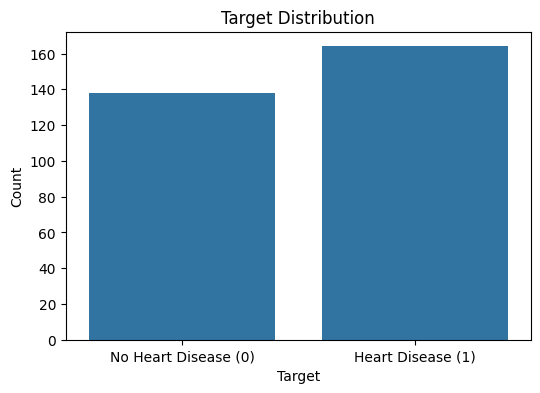

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(x='target', data=df)

plt.title('Target Distribution')
plt.xticks(
    [0, 1],
    ['No Heart Disease (0)', 'Heart Disease (1)']
)
plt.xlabel('Target')
plt.ylabel('Count')

plt.show()

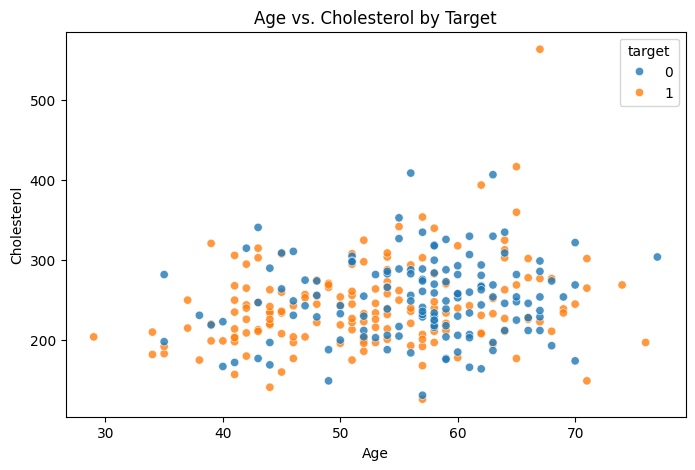

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='age',
    y='chol',
    hue='target',
    data=df,
    alpha=0.8
)

plt.title('Age vs. Cholesterol by Target')
plt.xlabel('Age')
plt.ylabel('Cholesterol')

plt.show()

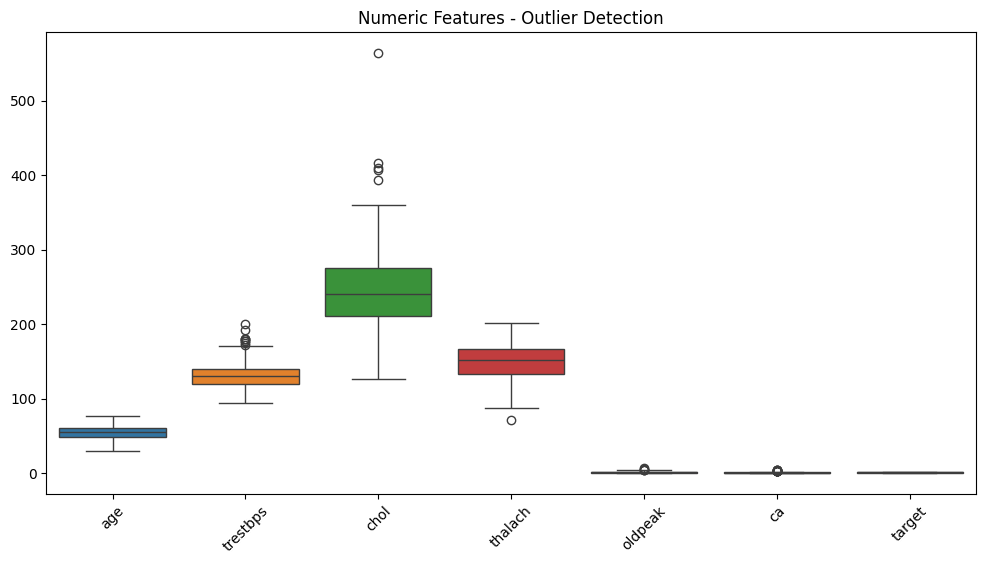

In [14]:
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[num_cols])

plt.title('Numeric Features - Outlier Detection')
plt.xticks(rotation=45)

plt.show()

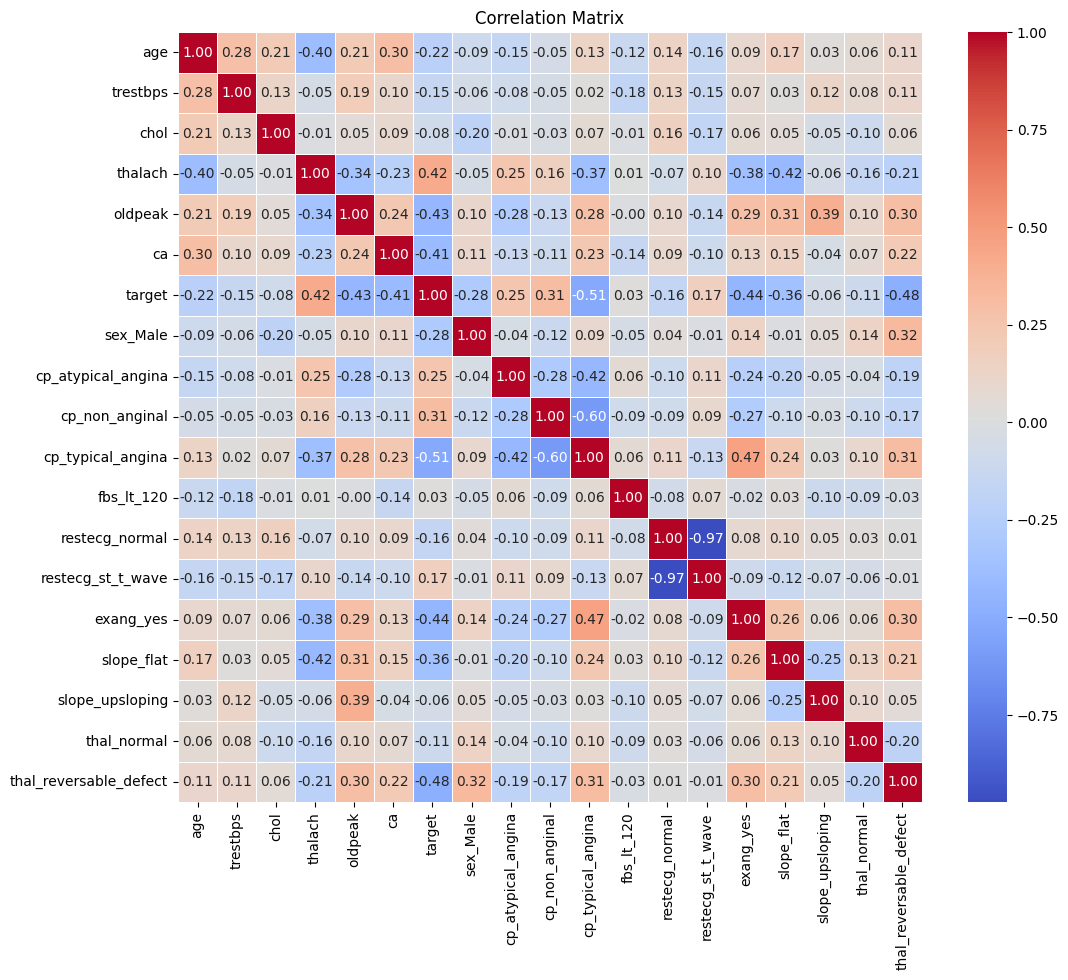

In [15]:
df_encoded = pd.get_dummies(df, drop_first=True)

corr_matrix = df_encoded.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Matrix')

plt.show()

In [16]:
X = df.drop(columns=['target'])

y = df['target']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age     sex               cp  trestbps  chol     fbs    restecg  thalach  \
0   63    Male     asymptomatic       145   233  gt_120     normal      150   
1   37    Male      non_anginal       130   250  lt_120  st_t_wave      187   
2   41  Female  atypical_angina       130   204  lt_120     normal      172   
3   56    Male  atypical_angina       120   236  lt_120  st_t_wave      178   
4   57  Female   typical_angina       120   354  lt_120  st_t_wave      163   

  exang  oldpeak        slope  ca          thal  
0    no      2.3    upsloping   0        normal  
1    no      3.5    upsloping   0  fixed_defect  
2    no      1.4  downsloping   0  fixed_defect  
3    no      0.8  downsloping   0  fixed_defect  
4   yes      0.6  downsloping   0  fixed_defect  

Target:
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


In [17]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

Categorical Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [18]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [19]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (241, 13)
Testing set: (61, 13)


In [22]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy='most_frequent'
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy * 100:.2f}%"
)

Baseline Accuracy: 54.10%


In [23]:
log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [24]:
log_pipeline.fit(X_train, y_train)

y_pred_log = log_pipeline.predict(X_test)

In [25]:
print(
    f"Logistic Regression Accuracy: "
    f"{accuracy_score(y_test, y_pred_log) * 100:.2f}%"
)

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred_log,
        target_names=[
            'No Disease (0)',
            'Disease (1)'
        ]
    )
)

print("--- Confusion Matrix ---")

print(
    confusion_matrix(
        y_test,
        y_pred_log
    )
)

Logistic Regression Accuracy: 80.33%

--- Classification Report ---
                precision    recall  f1-score   support

No Disease (0)       0.83      0.71      0.77        28
   Disease (1)       0.78      0.88      0.83        33

      accuracy                           0.80        61
     macro avg       0.81      0.80      0.80        61
  weighted avg       0.81      0.80      0.80        61

--- Confusion Matrix ---
[[20  8]
 [ 4 29]]


In [26]:
param_grid_log = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs']
}

In [27]:
grid_log = GridSearchCV(
    estimator=log_pipeline,
    param_grid=param_grid_log,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [28]:
print("Best Logistic Regression Parameters:")
print(grid_log.best_params_)

print(
    f"\nBest CV Accuracy: "
    f"{grid_log.best_score_ * 100:.2f}%"
)

Best Logistic Regression Parameters:
{'classifier__C': 0.1, 'classifier__solver': 'liblinear'}

Best CV Accuracy: 84.66%


In [29]:
best_log_model = grid_log.best_estimator_

y_pred_best_log = best_log_model.predict(X_test)

print(
    f"Test Accuracy: "
    f"{accuracy_score(y_test, y_pred_best_log) * 100:.2f}%"
)

Test Accuracy: 80.33%


In [30]:
k_values = range(1, 31)

knn_accuracies = []

In [31]:
for k in k_values:

    knn_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(
            n_neighbors=k
        ))
    ])

    knn_pipeline.fit(X_train, y_train)

    y_pred_knn_temp = knn_pipeline.predict(X_test)

    knn_accuracies.append(
        accuracy_score(
            y_test,
            y_pred_knn_temp
        )
    )

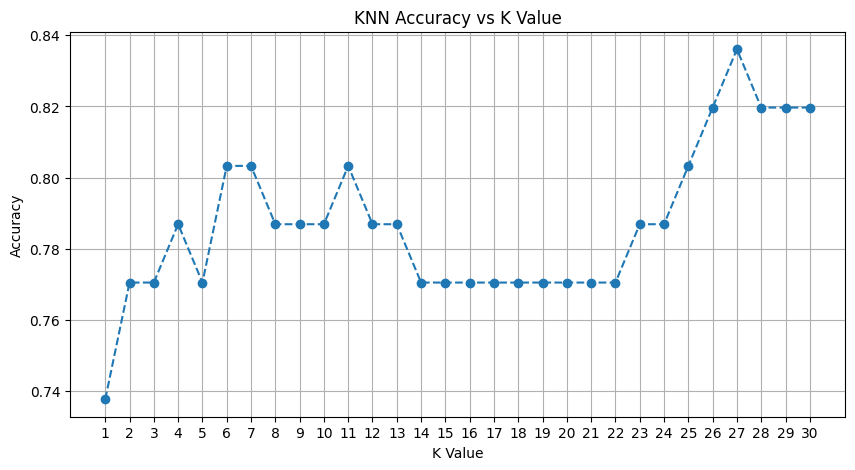

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    k_values,
    knn_accuracies,
    marker='o',
    linestyle='--'
)

plt.title('KNN Accuracy vs K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [33]:
best_k = k_values[
    np.argmax(knn_accuracies)
]

best_knn_accuracy = max(knn_accuracies)

print(
    f"Best K Value: {best_k}"
)

print(
    f"Best Accuracy: "
    f"{best_knn_accuracy * 100:.2f}%"
)

Best K Value: 27
Best Accuracy: 83.61%


In [34]:
best_knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=best_k
    ))
])

In [35]:
best_knn_pipeline.fit(
    X_train,
    y_train
)

y_pred_best_knn = best_knn_pipeline.predict(
    X_test
)

In [36]:
print(
    f"KNN Accuracy: "
    f"{accuracy_score(y_test, y_pred_best_knn) * 100:.2f}%"
)

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred_best_knn,
        target_names=[
            'No Disease (0)',
            'Disease (1)'
        ]
    )
)

print("--- Confusion Matrix ---")

print(
    confusion_matrix(
        y_test,
        y_pred_best_knn
    )
)

KNN Accuracy: 83.61%

--- Classification Report ---
                precision    recall  f1-score   support

No Disease (0)       0.91      0.71      0.80        28
   Disease (1)       0.79      0.94      0.86        33

      accuracy                           0.84        61
     macro avg       0.85      0.83      0.83        61
  weighted avg       0.85      0.84      0.83        61

--- Confusion Matrix ---
[[20  8]
 [ 2 31]]


In [37]:
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        random_state=42
    ))
])

In [38]:
svm_pipeline.fit(
    X_train,
    y_train
)

y_pred_svm = svm_pipeline.predict(
    X_test
)

In [39]:
print(
    f"SVM Accuracy: "
    f"{accuracy_score(y_test, y_pred_svm) * 100:.2f}%"
)

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            'No Disease (0)',
            'Disease (1)'
        ]
    )
)

print("--- Confusion Matrix ---")

print(
    confusion_matrix(
        y_test,
        y_pred_svm
    )
)

SVM Accuracy: 81.97%

--- Classification Report ---
                precision    recall  f1-score   support

No Disease (0)       0.95      0.64      0.77        28
   Disease (1)       0.76      0.97      0.85        33

      accuracy                           0.82        61
     macro avg       0.85      0.81      0.81        61
  weighted avg       0.85      0.82      0.81        61

--- Confusion Matrix ---
[[18 10]
 [ 1 32]]


In [40]:
param_grid_svm = {
    'classifier__C': [
        0.1,
        1,
        10,
        100
    ],

    'classifier__gamma': [
        'scale',
        'auto',
        0.01,
        0.1,
        1
    ],

    'classifier__kernel': [
        'rbf',
        'linear',
        'poly'
    ]
}

In [41]:
grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                                       ('classifier',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10, 100],
                         'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
                         'classifier__kernel': ['rbf', 'linear', 'poly']},
             scoring='accuracy')

In [42]:
print("Best SVM Parameters:")
print(grid_svm.best_params_)

print(
    f"\nBest CV Accuracy: "
    f"{grid_svm.best_score_ * 100:.2f}%"
)

Best SVM Parameters:
{'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}

Best CV Accuracy: 85.49%


In [43]:
best_svm_model = grid_svm.best_estimator_

y_pred_best_svm = best_svm_model.predict(
    X_test
)

In [44]:
print(
    f"Test Accuracy: "
    f"{accuracy_score(y_test, y_pred_best_svm) * 100:.2f}%"
)

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred_best_svm,
        target_names=[
            'No Disease (0)',
            'Disease (1)'
        ]
    )
)

Test Accuracy: 80.33%

--- Classification Report ---
                precision    recall  f1-score   support

No Disease (0)       0.86      0.68      0.76        28
   Disease (1)       0.77      0.91      0.83        33

      accuracy                           0.80        61
     macro avg       0.82      0.79      0.80        61
  weighted avg       0.81      0.80      0.80        61



In [45]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        max_depth=5,
        random_state=42
    ))
])

In [46]:
dt_pipeline.fit(
    X_train,
    y_train
)

y_pred_dt = dt_pipeline.predict(
    X_test
)

In [47]:
print(
    f"Decision Tree Accuracy: "
    f"{accuracy_score(y_test, y_pred_dt) * 100:.2f}%"
)

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=[
            'No Disease (0)',
            'Disease (1)'
        ]
    )
)

print("--- Confusion Matrix ---")

print(
    confusion_matrix(
        y_test,
        y_pred_dt
    )
)

Decision Tree Accuracy: 67.21%

--- Classification Report ---
                precision    recall  f1-score   support

No Disease (0)       0.67      0.57      0.62        28
   Disease (1)       0.68      0.76      0.71        33

      accuracy                           0.67        61
     macro avg       0.67      0.66      0.66        61
  weighted avg       0.67      0.67      0.67        61

--- Confusion Matrix ---
[[16 12]
 [ 8 25]]


In [48]:
param_grid_dt = {
    'classifier__criterion': [
        'gini',
        'entropy'
    ],

    'classifier__max_depth': [
        3,
        4,
        5,
        6,
        8,
        10,
        None
    ],

    'classifier__min_samples_split': [
        2,
        5,
        10,
        15
    ],

    'classifier__min_samples_leaf': [
        1,
        2,
        4,
        8
    ]
}

In [49]:
grid_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          O...
                                                                         Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                                       ('classifier',
                                        DecisionTreeClassifier(max_depth=5,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 4, 5, 6, 8, 10, None],
                         'classifier__min_samples_leaf': [1, 2, 4, 8],
                         'classifier__min_samples_split': [2, 5, 10, 15]},
             scoring='accuracy')

In [50]:
print("Best Decision Tree Parameters:")
print(grid_dt.best_params_)

print(
    f"\nBest CV Accuracy: "
    f"{grid_dt.best_score_ * 100:.2f}%"
)

Best Decision Tree Parameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 2}

Best CV Accuracy: 79.24%


In [51]:
best_dt_model = grid_dt.best_estimator_

y_pred_best_dt = best_dt_model.predict(
    X_test
)

In [52]:
print(
    f"Test Accuracy: "
    f"{accuracy_score(y_test, y_pred_best_dt) * 100:.2f}%"
)

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred_best_dt,
        target_names=[
            'No Disease (0)',
            'Disease (1)'
        ]
    )
)

Test Accuracy: 67.21%

--- Classification Report ---
                precision    recall  f1-score   support

No Disease (0)       0.67      0.57      0.62        28
   Disease (1)       0.68      0.76      0.71        33

      accuracy                           0.67        61
     macro avg       0.67      0.66      0.66        61
  weighted avg       0.67      0.67      0.67        61



In [53]:
feature_names = (
    best_dt_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

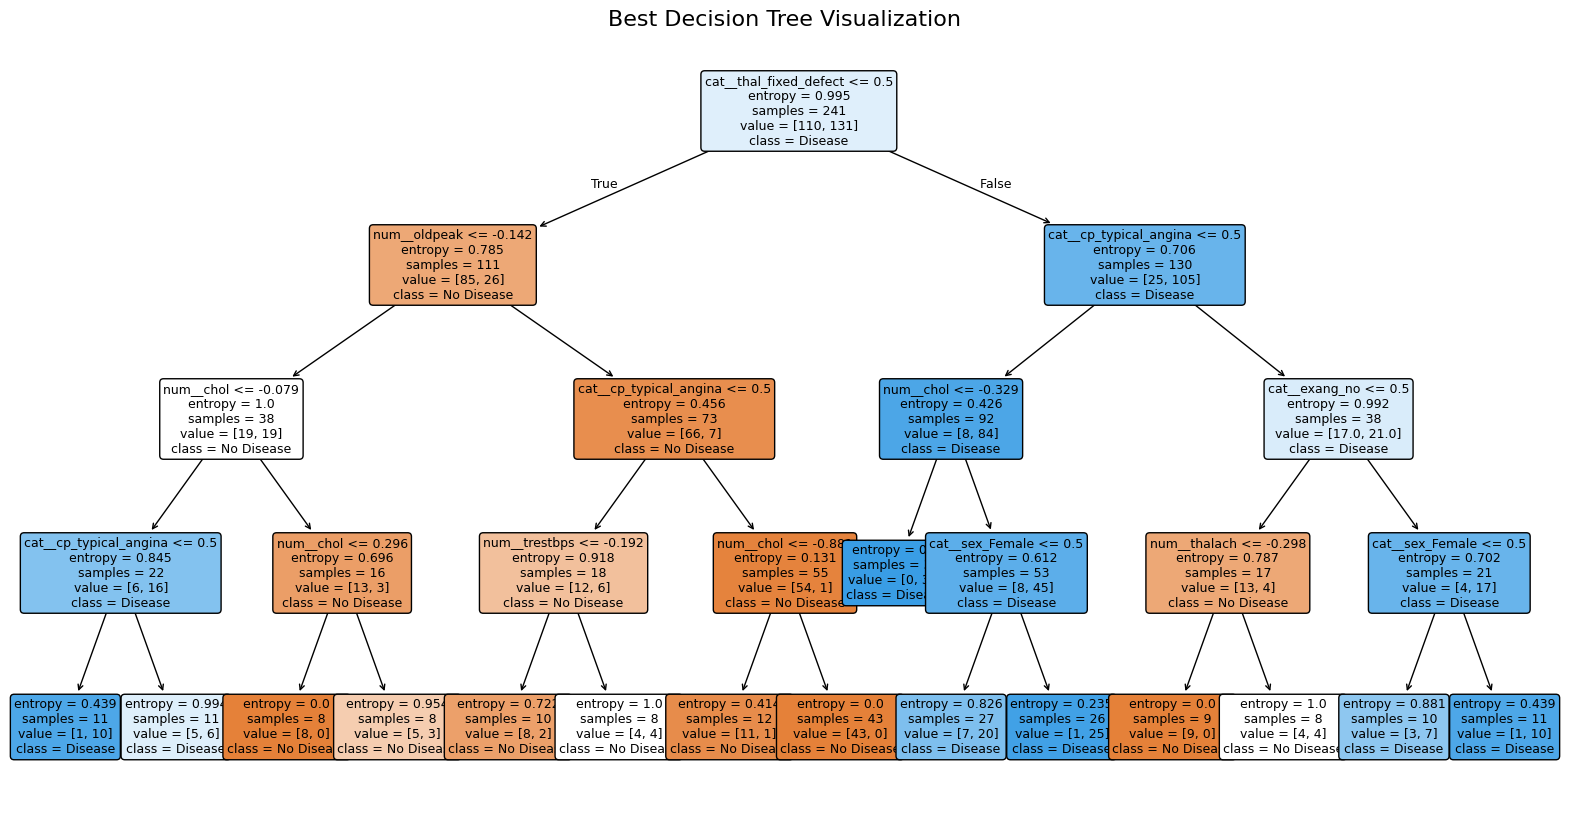

In [54]:
plt.figure(figsize=(20, 10))

plot_tree(
    best_dt_model.named_steps['classifier'],
    feature_names=feature_names,
    class_names=[
        'No Disease',
        'Disease'
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    'Best Decision Tree Visualization',
    fontsize=16
)

plt.show()

In [55]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [56]:
rf_pipeline.fit(
    X_train,
    y_train
)

y_pred_rf_initial = rf_pipeline.predict(
    X_test
)

In [57]:
print(
    f"Random Forest Accuracy: "
    f"{accuracy_score(y_test, y_pred_rf_initial) * 100:.2f}%"
)

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred_rf_initial,
        target_names=[
            'No Disease (0)',
            'Disease (1)'
        ]
    )
)

Random Forest Accuracy: 70.49%

--- Classification Report ---
                precision    recall  f1-score   support

No Disease (0)       0.75      0.54      0.62        28
   Disease (1)       0.68      0.85      0.76        33

      accuracy                           0.70        61
     macro avg       0.72      0.69      0.69        61
  weighted avg       0.71      0.70      0.70        61



In [58]:
param_grid_rf = {

    'classifier__n_estimators': [
        50,
        100,
        150
    ],

    'classifier__max_depth': [
        3,
        5,
        7,
        10,
        None
    ],

    'classifier__min_samples_split': [
        2,
        5,
        10
    ],

    'classifier__min_samples_leaf': [
        1,
        2,
        4
    ],

    'classifier__criterion': [
        'gini',
        'entropy'
    ]
}

In [59]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          O...
                                                                         Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 5, 7, 10, None],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [60]:
print("--- Best Random Forest Parameters ---")

for param_name, param_value in grid_rf.best_params_.items():

    print(
        f"{param_name.replace('classifier__', '')}: "
        f"{param_value}"
    )

print(
    f"\nBest Cross-Validation Accuracy: "
    f"{grid_rf.best_score_ * 100:.2f}%"
)

--- Best Random Forest Parameters ---
criterion: gini
max_depth: 3
min_samples_leaf: 4
min_samples_split: 10
n_estimators: 100

Best Cross-Validation Accuracy: 85.90%


In [61]:
best_rf_model = grid_rf.best_estimator_

y_pred_best_rf = best_rf_model.predict(
    X_test
)

In [62]:
print(
    f"Random Forest Test Accuracy: "
    f"{accuracy_score(y_test, y_pred_best_rf) * 100:.2f}%"
)

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred_best_rf,
        target_names=[
            'No Disease (0)',
            'Disease (1)'
        ]
    )
)

print("--- Confusion Matrix ---")

print(
    confusion_matrix(
        y_test,
        y_pred_best_rf
    )
)

Random Forest Test Accuracy: 80.33%

--- Classification Report ---
                precision    recall  f1-score   support

No Disease (0)       0.83      0.71      0.77        28
   Disease (1)       0.78      0.88      0.83        33

      accuracy                           0.80        61
     macro avg       0.81      0.80      0.80        61
  weighted avg       0.81      0.80      0.80        61

--- Confusion Matrix ---
[[20  8]
 [ 4 29]]


In [63]:
models = [
    'Logistic Regression',
    'KNN',
    'SVM',
    'Decision Tree',
    'Random Forest'
]

predictions = [
    y_pred_best_log,
    y_pred_best_knn,
    y_pred_best_svm,
    y_pred_best_dt,
    y_pred_best_rf
]

In [64]:
results = []

for model_name, pred in zip(models, predictions):

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

In [65]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.783784,0.878788,0.828571
1,KNN,0.836066,0.794872,0.939394,0.861111
2,SVM,0.803279,0.769231,0.909091,0.833333
3,Decision Tree,0.672131,0.675676,0.757576,0.714286
4,Random Forest,0.803279,0.783784,0.878788,0.828571


In [66]:
results_percentage = results_df.copy()

results_percentage[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
] *= 100

results_percentage

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,80.327869,78.378378,87.878788,82.857143
1,KNN,83.606557,79.487179,93.939394,86.111111
2,SVM,80.327869,76.923077,90.909091,83.333333
3,Decision Tree,67.213115,67.567568,75.757576,71.428571
4,Random Forest,80.327869,78.378378,87.878788,82.857143


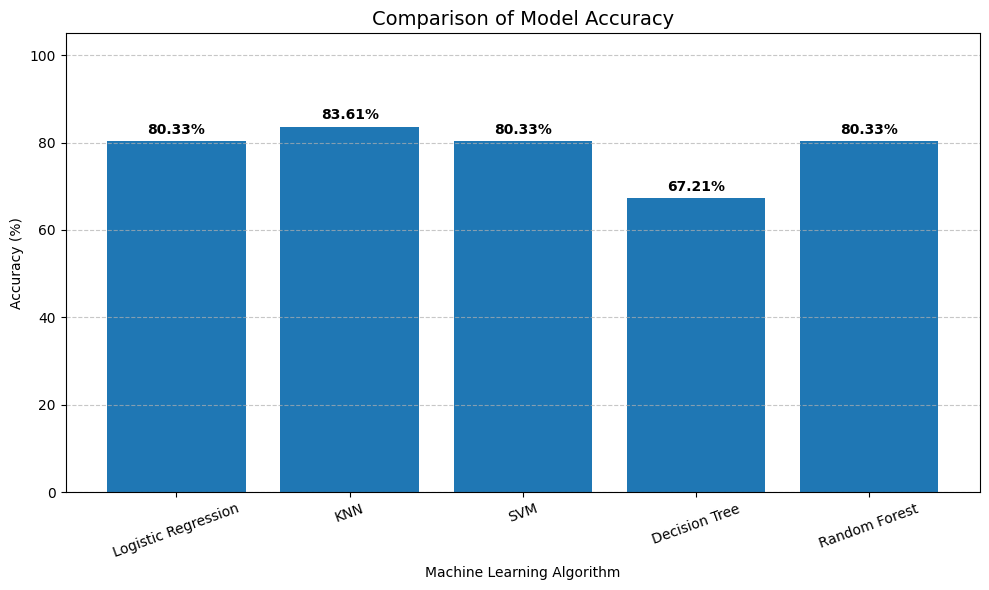

In [67]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    results_percentage['Model'],
    results_percentage['Accuracy']
)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title(
    'Comparison of Model Accuracy',
    fontsize=14
)

plt.xlabel('Machine Learning Algorithm')
plt.ylabel('Accuracy (%)')

plt.ylim(0, 105)

plt.xticks(rotation=20)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

plt.show()

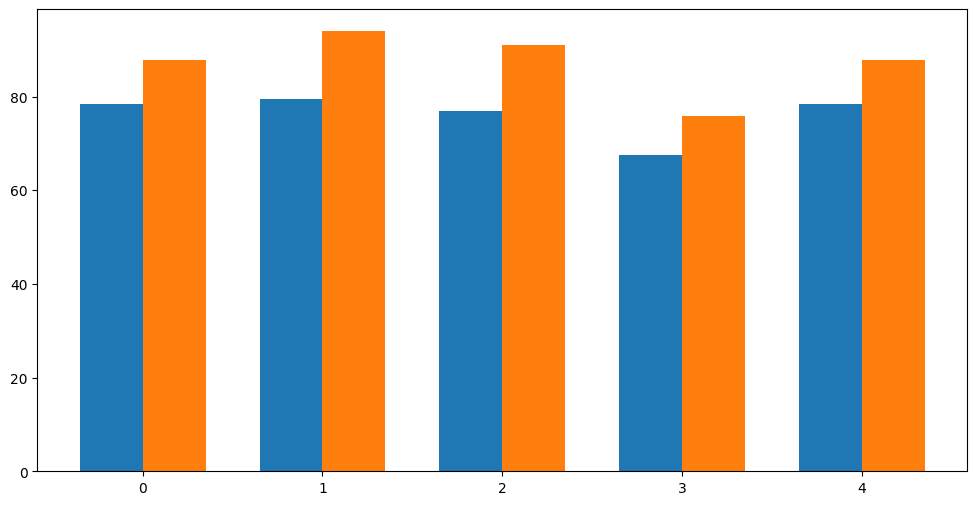

In [68]:
x = np.arange(len(models))

width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(
    x - width / 2,
    results_percentage['Precision'],
    width,
    label='Precision'
)

rects2 = ax.bar(
    x + width / 2,
    results_percentage['Recall'],
    width,
    label='Recall'
)

In [69]:
def add_labels(rects):

    for rect in rects:

        height = rect.get_height()

        ax.annotate(
            f'{height:.1f}%',
            xy=(
                rect.get_x() +
                rect.get_width() / 2,
                height
            ),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )


add_labels(rects1)
add_labels(rects2)

In [70]:
ax.set_ylabel('Percentage (%)')

ax.set_title(
    'Precision vs Recall Comparison'
)

ax.set_xticks(x)

ax.set_xticklabels(
    models,
    rotation=20
)

ax.set_ylim(0, 110)

ax.legend()

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.show()

<Figure size 640x480 with 0 Axes>

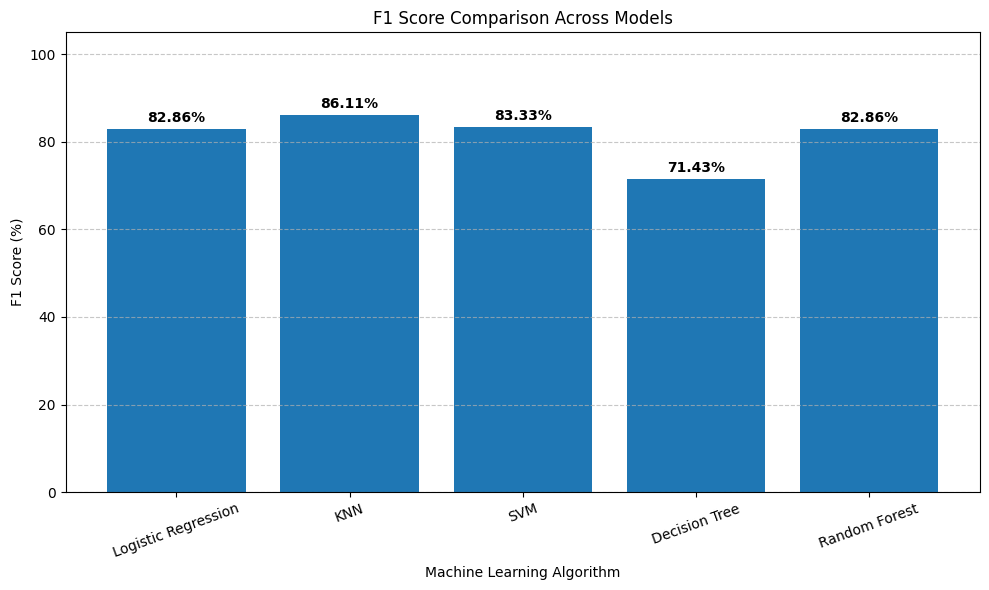

In [71]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    results_percentage['Model'],
    results_percentage['F1 Score']
)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title(
    'F1 Score Comparison Across Models'
)

plt.xlabel('Machine Learning Algorithm')
plt.ylabel('F1 Score (%)')

plt.ylim(0, 105)

plt.xticks(rotation=20)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

plt.show()

In [72]:
models_with_probability = {
    'Logistic Regression': best_log_model,
    'KNN': best_knn_pipeline,
    'SVM': best_svm_model,
    'Decision Tree': best_dt_model,
    'Random Forest': best_rf_model
}

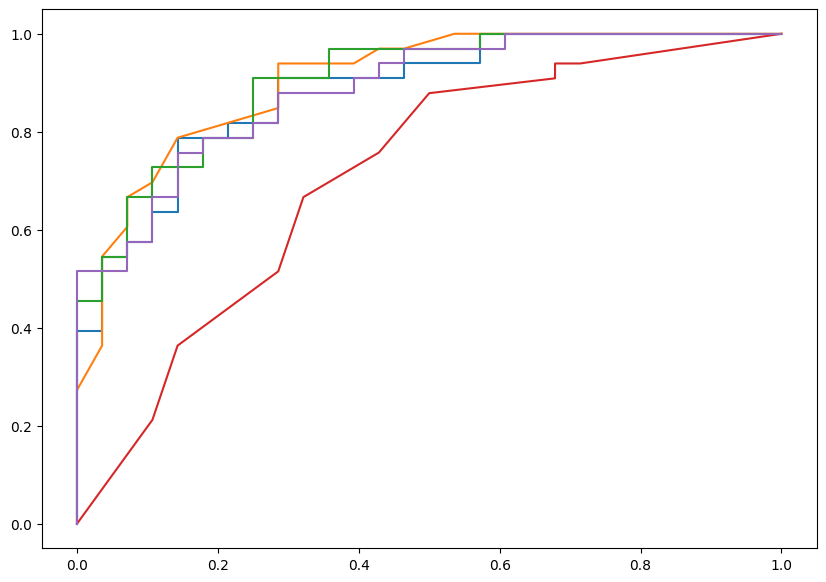

In [73]:
auc_results = {}

plt.figure(figsize=(10, 7))

for model_name, model in models_with_probability.items():

    y_probability = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_probability
    )

    auc_score = roc_auc_score(
        y_test,
        y_probability
    )

    auc_results[model_name] = auc_score

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc_score:.3f})'
    )

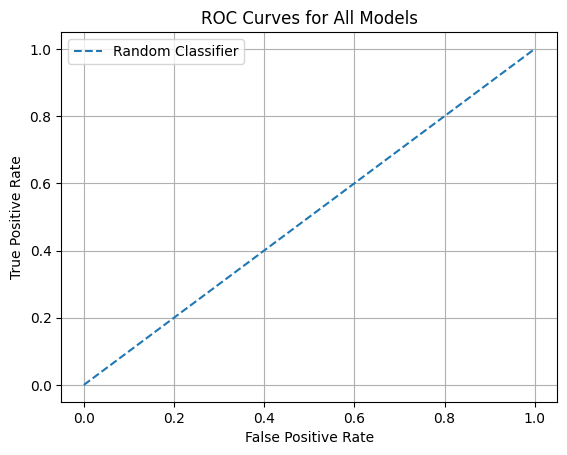

In [74]:
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curves for All Models')

plt.legend()

plt.grid(True)

plt.show()

In [75]:
for model_name, auc_score in auc_results.items():

    print(
        f"{model_name}: "
        f"AUC = {auc_score:.3f}"
    )

Logistic Regression: AUC = 0.883
KNN: AUC = 0.904
SVM: AUC = 0.902
Decision Tree: AUC = 0.710
Random Forest: AUC = 0.885


In [76]:
results_df['ROC-AUC'] = [
    auc_results['Logistic Regression'],
    auc_results['KNN'],
    auc_results['SVM'],
    auc_results['Decision Tree'],
    auc_results['Random Forest']
]

In [77]:
results_percentage = results_df.copy()

results_percentage[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
] *= 100

results_percentage

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,80.327869,78.378378,87.878788,82.857143,0.883117
1,KNN,83.606557,79.487179,93.939394,86.111111,0.903680
2,SVM,80.327869,76.923077,90.909091,83.333333,0.901515
3,Decision Tree,67.213115,67.567568,75.757576,71.428571,0.710498
4,Random Forest,80.327869,78.378378,87.878788,82.857143,0.885281


In [78]:
best_model_row = results_df.loc[
    results_df['Accuracy'].idxmax()
]

print("Best Model:")
print(best_model_row)

Best Model:
Model             KNN
Accuracy     0.836066
Precision    0.794872
Recall       0.939394
F1 Score     0.861111
ROC-AUC       0.90368
Name: 1, dtype: object


In [79]:
best_f1_model = results_df.loc[
    results_df['F1 Score'].idxmax()
]

print("Best Model Based on F1 Score:")
print(best_f1_model)

Best Model Based on F1 Score:
Model             KNN
Accuracy     0.836066
Precision    0.794872
Recall       0.939394
F1 Score     0.861111
ROC-AUC       0.90368
Name: 1, dtype: object


In [80]:
model_objects = {
    'Logistic Regression': best_log_model,
    'KNN': best_knn_pipeline,
    'SVM': best_svm_model,
    'Decision Tree': best_dt_model,
    'Random Forest': best_rf_model
}

In [81]:
best_model_name = best_model_row['Model']

best_pipeline = model_objects[
    best_model_name
]

print(
    f"Selected Best Model: "
    f"{best_model_name}"
)

Selected Best Model: KNN


In [82]:
joblib.dump(
    best_pipeline,
    'heart_disease_pipeline.pkl'
)

print(
    "Model saved successfully as "
    "'heart_disease_pipeline.pkl'"
)

Model saved successfully as 'heart_disease_pipeline.pkl'


In [83]:
loaded_pipeline = joblib.load(
    'heart_disease_pipeline.pkl'
)

print("Model loaded successfully!")

Model loaded successfully!


In [87]:
for col in categorical_features:

    print(
        f"{col}:",
        df[col].dropna().unique()
    )

sex: ['Male' 'Female']
cp: ['asymptomatic' 'non_anginal' 'atypical_angina' 'typical_angina']
fbs: ['gt_120' 'lt_120']
restecg: ['normal' 'st_t_wave' 'hypertrophy']
exang: ['no' 'yes']
slope: ['upsloping' 'downsloping' 'flat']
thal: ['normal' 'fixed_defect' 'reversable_defect']


In [88]:
new_patient = pd.DataFrame([{
    'age': 50,
    'sex': 'Male',
    'cp': 'Typical angina',
    'trestbps': 110,
    'chol': 254,
    'fbs': 'False',
    'restecg': 'Normal',
    'thalach': 159,
    'exang': 'No',
    'oldpeak': 0,
    'slope': 'Upsloping',
    'ca': 0,
    'thal': 'Normal'
}])

In [89]:
prediction = loaded_pipeline.predict(
    new_patient
)[0]

probability = loaded_pipeline.predict_proba(
    new_patient
)[0][1]

print("--- Model Prediction ---")

if prediction == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

print(
    f"Probability of Heart Disease: "
    f"{probability * 100:.1f}%"
)

--- Model Prediction ---
Prediction: Heart Disease
Probability of Heart Disease: 70.4%


In [91]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [92]:
joblib.dump(
    best_pipeline,
    '/content/drive/MyDrive/heart_disease_pipeline.pkl'
)

print(
    "Model saved successfully to Google Drive!"
)

Model saved successfully to Google Drive!
